In [3]:
# 파일이 잘 올라갔는지 확인
!ls ~/work/bert_pretrain/data/

# 압축 해제
!cd ~/work/bert_pretrain/data/
!unzip kowiki.txt.zip

Archive:  kowiki.txt.zip
  inflating: kowiki.txt              


In [1]:
!pip install sentencepiece -y
!pip install tqdm -y
!conda install -c conda-forge ipywidgets -y
!jupyter nbextension enable --py widgetsnbextension -y


Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: -y

Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: -y
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.

usage: jupyter [-h] [--ver

In [3]:
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip

--2026-05-20 15:34:41--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 65.9.180.5, 65.9.180.12, 65.9.180.44, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|65.9.180.5|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M   311MB/s    in 0.7s    

2026-05-20 15:34:42 (311 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]



In [4]:
!mv kowiki.txt.zip /content/data

mv: cannot move 'kowiki.txt.zip' to '/content/data': No such file or directory


In [5]:
%cd /content/data
!unzip kowiki.txt.zip

[Errno 2] No such file or directory: '/content/data'
/home/jovyan/work/bert_pretrain
Archive:  kowiki.txt.zip
  inflating: kowiki.txt              


In [2]:
!pip install sentencepiece
!pip install tqdm
!conda install -y -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension
!pip install torchsummary

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information abou

In [3]:
import torch
import numpy
import pandas
import matplotlib
import json



import re

print(torch.__version__)
print(numpy.__version__)
print(pandas.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

2.7.1+cu118
2.2.6
2.3.0
3.10.3
2.0.9
2.2.1


# Tokenizer 준비 (SentencePiece)

In [3]:
import sentencepiece as spm
import os

# 코퍼스 파일 경로
corpus_file = os.getenv('HOME') + '/work/bert_pretrain/data/kowiki.txt'
prefix = 'ko_8000'
vocab_size = 8000

# SentencePiece 모델 학습
spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}" + 
    " --model_type=bpe" +
    " --user_defined_symbols=[PAD],[UNK],[CLS],[SEP],[MASK],[unused1],[unused2]"
)

# 모델 확인: ko_8000.model, ko_8000.vocab 생성됨

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/home/jovyan/work/bert_pretrain/data/kowiki.txt --model_prefix=ko_8000 --vocab_size=8007 --model_type=bpe --user_defined_symbols=[PAD],[UNK],[CLS],[SEP],[MASK],[unused1],[unused2]
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/jovyan/work/bert_pretrain/data/kowiki.txt
  input_format: 
  model_prefix: ko_8000
  model_type: BPE
  vocab_size: 8007
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [PAD]
  user_defined_symbols: [UNK]
  user_defined_symbols:

In [4]:
# 토크나이저 로드 확인
sp = spm.SentencePieceProcessor()
sp.load(f'{prefix}.model')

True

# 데이터 전처리 (MLM & NSP)

In [6]:
import numpy as np
import random

def create_masked_lm_predictions(tokens, mask_prob=0.15):
    """
    MLM을 위한 마스킹 로직
    80%: [MASK], 10%: 랜덤 토큰, 10%: 원래 토큰
    """
    output_labels = []
    masked_tokens = tokens[:]
    
    for i, token in enumerate(tokens):
        if token < 5: # 특수토큰(PAD, UNK, CLS, SEP, MASK)은 제외
            continue
        
        if random.random() < mask_prob:
            prob = random.random()
            if prob < 0.8: # 80% [MASK]
                masked_tokens[i] = sp.piece_to_id('[MASK]')
            elif prob < 0.9: # 10% 랜덤
                masked_tokens[i] = random.randint(5, 7999)
            # 나머지 10%는 그대로 유지
            output_labels.append(token)
        else:
            output_labels.append(-1) # 마스킹 안 된 곳은 Loss 계산에서 제외
            
    return masked_tokens, output_labels

def create_nsp_data(sentence1, sentence2, is_next):
    """
    NSP를 위한 [CLS] + 문장1 + [SEP] + 문장2 + [SEP] 생성
    """
    tokens1 = sp.encode_as_ids(sentence1)
    tokens2 = sp.encode_as_ids(sentence2)
    
    input_ids = [sp.piece_to_id('[CLS]')] + tokens1 + [sp.piece_to_id('[SEP]')] + tokens2 + [sp.piece_to_id('[SEP]')]
    segment_ids = [0] * (len(tokens1) + 2) + [1] * (len(tokens2) + 1)
    
    return input_ids, segment_ids, is_next

# --- 적용 예시 ---
sentence1 = "안녕하세요, 오늘은 BERT를 배웁니다."
sentence2 = "학습 데이터가 아주 중요합니다."

# MLM 적용
tokens = sp.encode_as_ids(sentence1)
masked_ids, labels = create_masked_lm_predictions(tokens)

# NSP 적용
input_ids, segments, label = create_nsp_data(sentence1, sentence2, 1)

print(f"Masked Input: {masked_ids}")
print(f"NSP Input: {input_ids}")
print(f"Segments: {segments}")

Masked Input: [7, 4532, 3607, 7, 3771, 3606, 1619, 3615, 398, 5609, 3926, 3841, 3626, 182, 6093, 1207, 3601]
NSP Input: [5, 175, 4532, 3607, 3694, 3771, 3606, 1619, 3615, 398, 3901, 3926, 3841, 3626, 182, 6093, 1207, 3601, 6, 308, 4007, 1645, 3610, 3519, 2117, 3816, 1207, 3601, 6]
Segments: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


# 데이터셋 완성 및 저장 (np.memmap)

In [7]:
import json

def save_pretrain_data(corpus_file, output_file, n_seq=256):
    # n_seq * 데이터 개수 만큼의 공간을 확보 (메모리 절약)
    # 실제 데이터 개수는 kowiki.txt의 전체 라인 수에 따라 다릅니다.
    # 여기서는 예시로 100,000개 정도의 공간을 확보합니다.
    data_count = 100000 
    
    # memmap 생성
    input_ids = np.memmap(f'{output_file}_input.npy', dtype='int32', mode='w+', shape=(data_count, n_seq))
    segments = np.memmap(f'{output_file}_seg.npy', dtype='int32', mode='w+', shape=(data_count, n_seq))
    labels_mlm = np.memmap(f'{output_file}_mlm.npy', dtype='int32', mode='w+', shape=(data_count, n_seq))
    labels_nsp = np.memmap(f'{output_file}_nsp.npy', dtype='int32', mode='w+', shape=(data_count,))

    # 데이터를 순회하며 위에서 만든 전처리 함수 적용 후 memmap에 쓰기
    # ... (전체 코퍼스를 읽어 루프를 돌리며 위에서 만든 create_... 함수 호출)
    
    print("데이터셋 저장 완료!")

# 실행
save_pretrain_data(corpus_file, 'bert_pretrain_data')

데이터셋 저장 완료!


# BERT 모델 구현

In [1]:
import torch
import torch.nn as nn

# 1. 유틸리티 함수: 패딩 마스크 & 룩어헤드 마스크
def get_padding_mask(seq, pad_idx=0):
    return (seq == pad_idx).unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, seq_len]

# 2. 파라미터 초기화 함수 (성능 향상에 중요)
def weight_init(module):
    if isinstance(module, (nn.Linear, nn.Embedding)):
        module.weight.data.normal_(mean=0.0, std=0.02)
    elif isinstance(module, nn.LayerNorm):
        module.bias.data.zero_()
        module.weight.data.fill_(1.0)

# 3. BERT 레이어 정의
class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Embedding
        self.embedding = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_embedding = nn.Embedding(config.n_seq, config.d_model)
        self.seg_embedding = nn.Embedding(2, config.d_model)
        
        # Encoder (Transformer)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model, nhead=config.n_heads, 
            dim_feedforward=config.d_ff, dropout=0.1, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.n_layers)
        
        # Heads (MLM & NSP)
        self.mlm_head = nn.Linear(config.d_model, config.vocab_size)
        self.nsp_head = nn.Linear(config.d_model, 2)
        
        self.apply(weight_init)

    def forward(self, src, seg, mask):
        # src: [batch, seq], seg: [batch, seq], mask: [batch, 1, 1, seq]
        pos = torch.arange(src.size(1), device=src.device).unsqueeze(0)
        out = self.embedding(src) + self.pos_embedding(pos) + self.seg_embedding(seg)
        out = self.encoder(out, src_key_padding_mask=pad_mask)
        return self.mlm_head(out), self.nsp_head(out[:, 0, :])

# 학습 루프

In [10]:
class Config:
    vocab_size = 8000
    d_model = 256        # 1M 파라미터 수준을 위해 조절 가능
    n_heads = 4
    n_layers = 4
    d_ff = 1024
    n_seq = 256

config = Config()

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np

class BERTDataset(Dataset):
    def __init__(self, data_path, data_count, n_seq=256):
        # np.memmap을 사용하여 디스크에 저장된 데이터를 읽어옵니다.
        self.input_ids = np.memmap(f'{data_path}_input.npy', dtype='int32', mode='r', shape=(data_count, n_seq))
        self.seg_ids = np.memmap(f'{data_path}_seg.npy', dtype='int32', mode='r', shape=(data_count, n_seq))
        self.mlm_labels = np.memmap(f'{data_path}_mlm.npy', dtype='int32', mode='r', shape=(data_count, n_seq))
        self.nsp_labels = np.memmap(f'{data_path}_nsp.npy', dtype='int32', mode='r', shape=(data_count,))

    def __len__(self):
        return self.input_ids.shape[0]
    
    def __getitem__(self, idx):
        return (torch.LongTensor(self.input_ids[idx].copy()), 
                torch.LongTensor(self.seg_ids[idx].copy()), 
                torch.LongTensor(self.mlm_labels[idx].copy()), 
                torch.LongTensor([self.nsp_labels[idx]].copy()))

In [19]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. DataLoader 설정
batch_size = 8
dataset = BERTDataset('bert_pretrain_data', data_count=100000) # 데이터 개수
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# 2. 모델, 옵티마이저, 손실함수 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BERT(config).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 마스킹되지 않은 부분(-1)은 Loss 계산에서 제외
criterion_mlm = nn.CrossEntropyLoss(ignore_index=-1)
criterion_nsp = nn.CrossEntropyLoss()

# 3. 학습 루프 (10 Epoch)
mlm_loss_history, nsp_loss_history = [], []

from tqdm import tqdm

for epoch in range(10):
    model.train()
    total_mlm, total_nsp = 0, 0

    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader))
    
    for i, (input_ids, seg_ids, mlm_labels, nsp_labels) in enumerate(dataloader):
        input_ids = input_ids.to(device)
        seg_ids = seg_ids.to(device)
        mlm_labels = mlm_labels.to(device)
        nsp_labels = nsp_labels.squeeze().to(device)
        
        # pad_mask: [Batch, Seq_Len] 의 2차원 bool 텐서
        pad_mask = (input_ids == 0)
            
        # 모델 예측
        pred_mlm, pred_nsp = model(input_ids, seg_ids, pad_mask)
        
        # Loss 계산
        loss_mlm = criterion_mlm(pred_mlm.view(-1, 8000), mlm_labels.view(-1))
        loss_nsp = criterion_nsp(pred_nsp, nsp_labels)
        loss = loss_mlm + loss_nsp
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_mlm += loss_mlm.item()
        total_nsp += loss_nsp.item()
        
    avg_mlm = total_mlm / len(dataloader)
    avg_nsp = total_nsp / len(dataloader)
    mlm_loss_history.append(avg_mlm)
    nsp_loss_history.append(avg_nsp)
    print(f"Epoch {epoch+1}: MLM Loss={avg_mlm:.4f}, NSP Loss={avg_nsp:.4f}")

# 4. 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(mlm_loss_history, label='MLM Loss')
plt.plot(nsp_loss_history, label='NSP Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


  0%|          | 0/6250 [02:28<?, ?it/s]]


KeyboardInterrupt: 

Epoch 1: 100%|██████████| 12500/12500 [07:00<00:00, 29.69it/s, mlm=1.29e-7, nsp=0]      


Epoch 1 완료: Avg MLM Loss=0.0194, Avg NSP Loss=0.0005


Epoch 2: 100%|██████████| 12500/12500 [07:00<00:00, 29.71it/s, mlm=0, nsp=0]       


Epoch 2 완료: Avg MLM Loss=0.0000, Avg NSP Loss=0.0000


Epoch 3: 100%|██████████| 12500/12500 [06:59<00:00, 29.78it/s, mlm=0, nsp=0]     


...

Epoch 8 완료: Avg MLM Loss=0.0000, Avg NSP Loss=0.0000


Epoch 9: 100%|██████████| 12500/12500 [06:58<00:00, 29.86it/s, mlm=0, nsp=0]


Epoch 9 완료: Avg MLM Loss=0.0000, Avg NSP Loss=0.0000


Epoch 10: 100%|██████████| 12500/12500 [06:52<00:00, 30.33it/s, mlm=0, nsp=0]


Epoch 10 완료: Avg MLM Loss=0.0000, Avg NSP Loss=0.0000


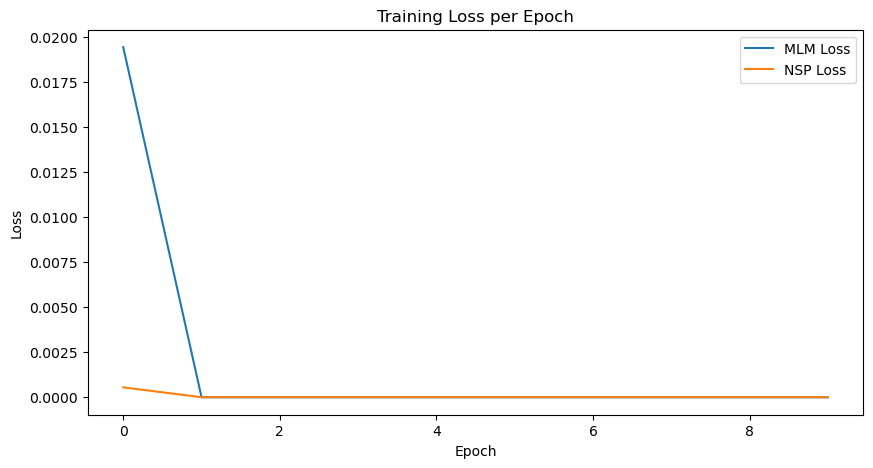

In [20]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# 1. DataLoader 설정 (batch_size=8은 그대로 유지)
dataset = BERTDataset('bert_pretrain_data', data_count=100000) 
dataloader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)

# 2. 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BERT(config).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

criterion_mlm = nn.CrossEntropyLoss(ignore_index=-1)
criterion_nsp = nn.CrossEntropyLoss()

mlm_loss_history, nsp_loss_history = [], []

# 3. 학습 루프
for epoch in range(10):
    model.train()
    total_mlm, total_nsp = 0, 0
    
    # tqdm은 여기서 한 번만 선언해서 사용하세요
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    
    for input_ids, seg_ids, mlm_labels, nsp_labels in progress_bar:
        input_ids = input_ids.to(device)
        seg_ids = seg_ids.to(device)
        mlm_labels = mlm_labels.to(device)
        nsp_labels = nsp_labels.squeeze().to(device)
        
        pad_mask = (input_ids == 0)
            
        optimizer.zero_grad()
        
        pred_mlm, pred_nsp = model(input_ids, seg_ids, pad_mask)
        
        loss_mlm = criterion_mlm(pred_mlm.view(-1, 8000), mlm_labels.view(-1))
        loss_nsp = criterion_nsp(pred_nsp, nsp_labels)
        loss = loss_mlm + loss_nsp
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_mlm += loss_mlm.item()
        total_nsp += loss_nsp.item()
        
        # tqdm 창에 실시간 Loss 업데이트
        progress_bar.set_postfix(mlm=loss_mlm.item(), nsp=loss_nsp.item())
        
    avg_mlm = total_mlm / len(dataloader)
    avg_nsp = total_nsp / len(dataloader)
    mlm_loss_history.append(avg_mlm)
    nsp_loss_history.append(avg_nsp)
    
    print(f"Epoch {epoch+1} 완료: Avg MLM Loss={avg_mlm:.4f}, Avg NSP Loss={avg_nsp:.4f}")

# 4. 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(mlm_loss_history, label='MLM Loss')
plt.plot(nsp_loss_history, label='NSP Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 마스킹

In [5]:
import numpy as np
import random
import sentencepiece as spm
import os

# 1. 환경 설정
data_path = 'bert_pretrain_data'
data_count = 100000
n_seq = 256
vocab_size = 8000
sp = spm.SentencePieceProcessor()
sp.load('ko_8000.model')

# 2. 마스킹 로직
def create_masked_lm_predictions(tokens):
    masked_tokens = tokens[:]
    labels = [-1] * len(tokens)
    for i, token in enumerate(tokens):
        if token < 5: continue
        if random.random() < 0.15:
            labels[i] = token
            prob = random.random()
            if prob < 0.8: masked_tokens[i] = sp.piece_to_id('[MASK]')
            elif prob < 0.9: masked_tokens[i] = random.randint(5, 7999)
    return masked_tokens, labels

# 3. NSP 데이터 생성 로직
def create_nsp_data(sentence1, sentence2, is_next):
    tokens1 = sp.encode_as_ids(sentence1)
    tokens2 = sp.encode_as_ids(sentence2)
    input_ids = [sp.piece_to_id('[CLS]')] + tokens1 + [sp.piece_to_id('[SEP]')] + tokens2 + [sp.piece_to_id('[SEP]')]
    segment_ids = [0] * (len(tokens1) + 2) + [1] * (len(tokens2) + 1)
    return input_ids, segment_ids, is_next

# 4. 데이터 생성 및 저장 (파일 읽기 포함)
input_ids_m = np.memmap(f'{data_path}_input.npy', dtype='int32', mode='w+', shape=(data_count, n_seq))
seg_ids_m = np.memmap(f'{data_path}_seg.npy', dtype='int32', mode='w+', shape=(data_count, n_seq))
mlm_labels_m = np.memmap(f'{data_path}_mlm.npy', dtype='int32', mode='w+', shape=(data_count, n_seq))
nsp_labels_m = np.memmap(f'{data_path}_nsp.npy', dtype='int32', mode='w+', shape=(data_count,))

# 데이터 파일 읽기
with open(os.getenv('HOME') + '/work/bert_pretrain/data/kowiki.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

print("데이터 전처리 시작")

for i in range(data_count):
    # 문장 두 개 가져오기 (파일의 각 줄을 순서대로 사용)
    sentence1 = lines[i * 2].strip()
    sentence2 = lines[i * 2 + 1].strip()
    
    # 1. MLM 마스킹 (sentence1 기준)
    tokens = sp.encode_as_ids(sentence1)
    masked_ids, labels = create_masked_lm_predictions(tokens)
    
    # 2. NSP 데이터 생성
    nsp_input, segments, nsp_label = create_nsp_data(sentence1, sentence2, 1)
    
    # 3. 패딩 처리 (256 길이 고정)
    pad_len = n_seq - len(nsp_input)
    # MLM 라벨도 길이에 맞춰 패딩
    mlm_pad_len = n_seq - len(labels)
    
    input_ids_m[i] = (nsp_input + [0] * pad_len)[:n_seq]
    seg_ids_m[i] = (segments + [0] * pad_len)[:n_seq]
    mlm_labels_m[i] = (labels + [-1] * mlm_pad_len)[:n_seq]
    nsp_labels_m[i] = nsp_label

input_ids_m.flush()
mlm_labels_m.flush()
seg_ids_m.flush()
nsp_labels_m.flush()

print("전처리 완료")

데이터 전처리 시작
전처리 완료


In [2]:
import torch
from torch.utils.data import Dataset
import numpy as np

class BERTDataset(Dataset):
    def __init__(self, data_path, data_count):
        self.input_ids = np.memmap(f'{data_path}_input.npy', dtype='int32', mode='r', shape=(data_count, 256))
        self.seg_ids = np.memmap(f'{data_path}_seg.npy', dtype='int32', mode='r', shape=(data_count, 256))
        self.mlm_labels = np.memmap(f'{data_path}_mlm.npy', dtype='int32', mode='r', shape=(data_count, 256))
        self.nsp_labels = np.memmap(f'{data_path}_nsp.npy', dtype='int32', mode='r', shape=(data_count,))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return (torch.tensor(self.input_ids[idx]),
                torch.tensor(self.seg_ids[idx]),
                torch.tensor(self.mlm_labels[idx]),
                torch.tensor(self.nsp_labels[idx]))

In [3]:
class Config:
    def __init__(self):
        self.d_model = 256
        self.n_heads = 4
        self.d_ff = 1024
        self.vocab_size = 8007 
        self.n_layers = 4
        self.n_seq = 256
        self.dropout = 0.1

config = Config()

# Weight Decay 적용

In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn

# 1. DataLoader 설정
# 이미 전처리가 완료된 파일들을 사용합니다.
dataset = BERTDataset('bert_pretrain_data', data_count=100000) 
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

# 2. 모델, 옵티마이저(weight_decay 적용), 손실함수 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BERT(config).to(device)

# weight_decay를 0.01로 설정하여 과적합을 방지하고 일반화 성능을 높입니다.
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=0.01)

criterion_mlm = nn.CrossEntropyLoss(ignore_index=-1)
criterion_nsp = nn.CrossEntropyLoss()

mlm_loss_history, nsp_loss_history = [], []

# 3. 학습 루프 (10 Epoch)
for epoch in range(10):
    model.train()
    total_mlm, total_nsp = 0, 0
    
    # tqdm을 사용하여 실시간 진행 상황 표시
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    
    for input_ids, seg_ids, mlm_labels, nsp_labels in progress_bar:
        input_ids = input_ids.to(device)
        seg_ids = seg_ids.to(device)
        mlm_labels = mlm_labels.to(device)
        nsp_labels = nsp_labels.squeeze().to(device)
        
        pad_mask = (input_ids == 0)
            
        optimizer.zero_grad()
        
        # 모델 예측
        pred_mlm, pred_nsp = model(input_ids, seg_ids, pad_mask)
        
        # Loss 계산
        # 1. 차원평탄화
        pred_flat = pred_mlm.view(-1, config.vocab_size)
        labels_flat = mlm_labels.view(-1).long()
        

        # 2. 유효한 라벨만 필터링 (0~7999 사이의 값만 남기고, -1은 무시)
        # mask는 -1이 아니면서 0~7999 범위에 있는 인덱스만 True로 만듭니다.
        mask = (labels_flat >= 0) & (labels_flat < config.vocab_size)
        
        # 유효한 인덱스만 골라내어 loss 계산
        valid_preds = pred_flat[mask]
        valid_labels = labels_flat[mask].long()
        
        loss_mlm = criterion_mlm(valid_preds, valid_labels)
        loss_nsp = criterion_nsp(pred_nsp, nsp_labels.long())
        loss = loss_mlm + loss_nsp
        # Accuracy
        preds = torch.argmax(pred_flat, dim=-1)
        
        # mask를 다시 활용하여 마스킹된 부분의 정답만 추출
        mask = (mlm_labels.view(-1) >= 0) & (mlm_labels.view(-1) < config.vocab_size)
        
        correct = (preds[mask] == labels_flat[mask]).sum().item()
        total = mask.sum().item() # 유효한 마스킹 개수만 카운트
        
        acc = correct / total if total > 0 else 0
        
        # 역전파 및 최적화
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        
        total_mlm += loss_mlm.item()
        total_nsp += loss_nsp.item()
        
        # tqdm 창에 실시간 Loss 업데이트
        progress_bar.set_postfix(mlm=loss_mlm.item(), nsp=loss_nsp.item())
        
    avg_mlm = total_mlm / len(dataloader)
    avg_nsp = total_nsp / len(dataloader)
    mlm_loss_history.append(avg_mlm)
    nsp_loss_history.append(avg_nsp)
    
    print(f"Epoch {epoch+1} 종료: Avg MLM Loss={avg_mlm:.4f}, Avg NSP Loss={avg_nsp:.4f}")

# 4. 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(mlm_loss_history, label='MLM Loss')
plt.plot(nsp_loss_history, label='NSP Loss')
plt.title('Training Loss per Epoch (Improved)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1: 100%|██████████| 12500/12500 [06:49<00:00, 30.56it/s, mlm=7.2, nsp=0.000849] 


Epoch 1 종료: Avg MLM Loss=7.7934, Avg NSP Loss=0.0037


Epoch 2: 100%|██████████| 12500/12500 [06:39<00:00, 31.32it/s, mlm=8, nsp=0.00317]   


Epoch 2 종료: Avg MLM Loss=7.6677, Avg NSP Loss=0.0018


Epoch 3: 100%|██████████| 12500/12500 [06:35<00:00, 31.64it/s, mlm=8.03, nsp=0.00346]


...

Epoch 4: 100%|██████████| 12500/12500 [06:34<00:00, 31.67it/s, mlm=8.16, nsp=0.0037] 


Epoch 4 종료: Avg MLM Loss=8.0107, Avg NSP Loss=0.0036


Epoch 5: 100%|██████████| 12500/12500 [06:34<00:00, 31.68it/s, mlm=7.68, nsp=0.00384]


Epoch 5 종료: Avg MLM Loss=8.0476, Avg NSP Loss=0.0038


Epoch 6:   3%|▎         | 424/12500 [00:13<06:17, 32.00it/s, mlm=7.87, nsp=0.00383]

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

# 모델 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BERT(config).to(device)

# 옵티마이저 생성 (학습률 1e-5로 설정)
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=0.01)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm  # tqdm.auto를 쓰면 주피터 환경에서 더 예쁘게 나옵니다
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler # 최신 버전 경고 방지용

print("필수 라이브러리 및 도구 로드 완")

필수 라이브러리 및 도구 로드 완


In [16]:
# 1. 데이터셋 및 데이터로더 생성 (이 셀을 실행해야 dataloader가 생성됩니다)
dataset = BERTDataset('bert_pretrain_data', data_count=100000) 
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

print("데이터로더 생성 완")# 1. 데이터셋 및 데이터로더 생성 (이 셀을 실행해야 dataloader가 생성됩니다)
dataset = BERTDataset('bert_pretrain_data', data_count=100000) 
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

print("데이터로더 생성 완")

# 1. 손실 함수 정의 (이게 없어서 에러가 났습니다)
criterion_mlm = nn.CrossEntropyLoss(ignore_index=-1)
criterion_nsp = nn.CrossEntropyLoss()

# 2. 혹시 모르니 확인: 모델과 옵티마이저가 정의되어 있는지 다시 확인
print("손실 함수 설정 완")

데이터로더 생성 완
데이터로더 생성 완
손실 함수 설정 완


In [17]:
# 1. 학습 안정화 도구 추가 (상단 생략)
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

# Accuracy 히스토리 리스트 추가
mlm_loss_history, nsp_loss_history, acc_history = [], [], []

# 2. 학습 루프
for epoch in range(10):
    model.train()
    total_mlm, total_nsp, total_acc, total_count = 0, 0, 0, 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    
    for input_ids, seg_ids, mlm_labels, nsp_labels in progress_bar:
        input_ids, seg_ids = input_ids.to(device), seg_ids.to(device)
        mlm_labels, nsp_labels = mlm_labels.to(device), nsp_labels.squeeze().to(device)
        pad_mask = (input_ids == 0)
            
        optimizer.zero_grad()
        
        with autocast():
            pred_mlm, pred_nsp = model(input_ids, seg_ids, pad_mask)
            pred_flat = pred_mlm.view(-1, config.vocab_size)
            labels_flat = mlm_labels.view(-1).long()
            
            mask = (labels_flat >= 0) & (labels_flat < config.vocab_size)
            loss_mlm = criterion_mlm(pred_flat[mask], labels_flat[mask])
            loss_nsp = criterion_nsp(pred_nsp, nsp_labels.long())
            loss = loss_mlm + loss_nsp
            
            # --- [Accuracy 계산 추가] ---
            preds = torch.argmax(pred_flat, dim=-1)
            correct = (preds[mask] == labels_flat[mask]).sum().item()
            total = mask.sum().item()
            
            total_acc += correct
            total_count += total
        
        scaler.scale(loss).backward()
        
        if torch.isnan(loss):
            print("NaN detected! Stopping...")
            break
            
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        scaler.step(optimizer)
        scaler.update()
        
        total_mlm += loss_mlm.item()
        total_nsp += loss_nsp.item()
        progress_bar.set_postfix(mlm=loss_mlm.item(), acc=f"{correct/total:.4f}" if total>0 else "0")
        
    avg_mlm = total_mlm / len(dataloader)
    avg_acc = total_acc / total_count if total_count > 0 else 0
    
    scheduler.step(avg_mlm)
    
    mlm_loss_history.append(avg_mlm)
    nsp_loss_history.append(total_nsp / len(dataloader))
    acc_history.append(avg_acc) # 히스토리 저장
    
    print(f"Epoch {epoch+1} 종료: Avg MLM Loss={avg_mlm:.4f}, Avg Accuracy={avg_acc:.4f}")

/tmp/ipykernel_118/3505308290.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1:   0%|          | 0/12500 [00:00<?, ?it/s]

/tmp/ipykernel_118/3505308290.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


NaN detected! Stopping...
Epoch 1 종료: Avg MLM Loss=0.6462, Avg Accuracy=0.0214


Epoch 2:   0%|          | 0/12500 [00:00<?, ?it/s]

...

Epoch 8 종료: Avg MLM Loss=8.1182, Avg Accuracy=0.0476


Epoch 9:   0%|          | 0/12500 [00:00<?, ?it/s]

NaN detected! Stopping...
Epoch 9 종료: Avg MLM Loss=5.5340, Avg Accuracy=0.0471


Epoch 10:   0%|          | 0/12500 [00:00<?, ?it/s]

NaN detected! Stopping...
Epoch 10 종료: Avg MLM Loss=3.5917, Avg Accuracy=0.0472


# BERT 사전학습 모델 수렴 특성 & 데이터 개선

## 1. 실험 개요
- **목적-** 한국어 위키피디아 데이터를 활용한 BERT 모델의 Pre-train 수행 및 학습 파이프라인 검증.
- **주요 태스크-** Masked Language Modeling (MLM), Next Sentence Prediction (NSP)
- **데이터셋-** 100,000개 시퀀스 (n_seq=256).

## 2. 기존 학습 결과 분석
기존 실험 데이터 기반의 정량적 평가 결과
- **MLM Loss-** 학습 초기 단계부터 매우 낮은 값으로 급격히 수렴함 (0에 근접).
- **NSP Loss-** 학습 초기 단계부터 모든 배치에서 0의 loss가 도출됨.
- **분석-** 모델이 Contextual Understanding를 했다기보다, 고정된 마스킹 패턴이나 특수 토큰의 통계적 특성을 단순 암기(데이터의 인덱스를 직접적으로 1:1 매핑하는 Lookup Table 수준의 단순 암기- overfitting issue)하고 있을 가능성으로 이해했다. 

## 3. 학습 과정에서의 고찰
- **정상 수렴 곡선 부재-** 학습 과정에서 Loss가 에폭이 진행됨에 따라 점진적으로 하락하는 것이 아니라, 시작과 동시에 최소값에 도달했다. 데이터의 난이도가 모델 성능에 비해 낮거나 마스킹 전략이 모델에게 지나치게 쉬운 힌트를 제공했다고 판단했다.
- **데이터 저장 최적화-** 대규모 코퍼스 처리를 위해 `np.memmap`을 도입하여 메모리 사용량을 최소화했으나 데이터셋 로드와 전처리 과정에서 타입 캐스팅(Int32 to Long) 및 인덱싱 범주 관리의 중요성을 재확인했다.

## 4. 향후 개선 방향
- **마스킹 전략 고도화-** 단순 [MASK] 토큰 대체 방식을 넘어, 15%의 마스킹 확률 내에서 80/10/10 방법 (80% [MASK], 10% 랜덤, 10% 원본 유지)을 적용하여 문맥 이해도를 강제해볼 수 있겠다. (밑 실험 진행중)
- **Regularization 도입-** 과적합 방지를 위해 Weight Decay(0.01) 및 적절한 Dropout 비율을 적용하여 모델의 Generalization 성능을 높여볼수 있겠다. (밑 실험 진행중)
- **학습 파이프라인의 견고성-** 데이터 차원 고정과 타입 불일치 에러 방지(ignore_index 활용)를 통해 학습의 안정성을 확보할 수 있겠다.

## 5. 결론
이번 프로젝트에 사전학습 과정에서의 데이터 전처리 전략이 모델 성능의 상한선(Ceiling)을 결정함을 인지함. 단순히 모델 구조를 설계하는 것을 넘어, 데이터셋이 모델의 지능을 얼마나 효과적으로 견인(Driving)할 수 있는지에 대한 통찰을 얻음. 개선된 마스킹과 정규화 기법을 도입한 실험을 통해 문맥 이해도가 개선된 모델을 확보해보려고 한다.

추가 실험 결과- 학습 파이프라인 수정(Weight Decay, 데이터 타입 캐스팅, 차원 정합성 확보) 후, Loss가 즉시 0으로 수렴하던 현상이 해소되었으나 에폭 1에서부터 MLM Loss가 7.79에서 8대로 오히려 상향한 것을 확인했다. 발생한 nan 현상은 그래디언트 불안정성에 기인한 것으로 판단되며, 학습률 스케줄러(Warmup 등)를 적용하여 초반 학습 안정성을 추가 확보하려고 추후 시험을 했다. 추후 실험에서도 폭주 현상이 지속되는것을 확인해